In [1]:
# GPU and TensorFlow runtime configuration — run this cell FIRST after a kernel restart.
#
# Purpose:
# - Configure TensorFlow's GPU allocator and optional mixed-precision policy.
# - Enable memory growth so TensorFlow does not pre-allocate the entire GPU memory at startup.
#
# Notes for a non-TensorFlow reader:
# - Mixed precision (float16 compute + float32 accumulation) reduces GPU memory and can speed up training on modern GPUs.
# - Any changes to these environment variables or policies require a kernel restart to take effect.
# - If you see OOM (out-of-memory) errors, re-run this cell after restarting the kernel, or disable mixed precision.

import os
# Optional: allow a more forgiving autotuner if you need to experiment with fallback autotuning
# os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'
# Use the cuda_malloc_async allocator to reduce fragmentation on newer CUDA versions.
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import tensorflow as tf
# list physical GPU devices available to TensorFlow
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth for each GPU to avoid TF pre-allocating all memory.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('Enabled memory growth for GPUs:', gpus)
    except Exception as e:
        # If enabling memory growth fails, print the exception to help debugging.
        print('Could not set memory growth:', e)
else:
    print('No GPU found')

# Mixed precision: this instructs Keras to use float16 where safe and float32 where needed.
# IMPORTANT: restart kernel and run this cell before creating the model or optimizer.
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', mixed_precision.global_policy())

2025-11-26 01:44:33.260631: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Enabled memory growth for GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [2]:
# Standard data science imports with short explanation for each:
import numpy as np            # numerical arrays (used for HDF5 reads and preprocessing)
import pandas as pd           # convenient data frames if needed for summaries / logs
import matplotlib.pyplot as plt  # plotting library used for visualizing training curves
import seaborn as sns         # nicer plotting aesthetics (optional)
import tensorflow as tf      # main ML library (Keras API) used for model and training
import sklearn as skl        # scikit-learn utilities (we use train_test_split)
import os                    # interaction with filesystem
import h5py as h5            # read HDF5 files containing the dataset
from sklearn.model_selection import train_test_split  # split indices into train/val/test

In [4]:
# Path to the HDF5 dataset file. Change this if your dataset is in another location.
h5_path = 'fractal_dataset.h5'

# build_index_array: scan the HDF5 file and create a small in-memory index.
# Returns:
# - index_list: a Python list of tuples (group_name, image_index, k_value) for every image
# - label2class: a dictionary mapping the k_value (e.g., 2,4,8...) to a small integer class id
# - label_names: sorted list of the distinct k values (useful for interpreting outputs)
def build_index_array(h5_path):
    index_list = []
    label_names =[]
    
    # Open the file in read-only mode and iterate over groups that start with 'k_'.
    with h5.File(h5_path, 'r') as f:
        groups = sorted([g for g in f.keys() if g.startswith('k_')])
        for g in groups:
            # extract k value from the group name, e.g., 'k_8' -> 8
            k_val = int(g.split('_')[1])
            # number of images in this group
            n = f[f"{g}/images"].shape[0]
            for i in range(n):
                # append a lightweight tuple describing where to find the image
                index_list.append((g, int(i), int(k_val)))
            label_names.append(k_val)
    # canonicalize and sort label names, then map them to 0..N-1
    label_names = sorted(list(set(label_names)))
    label2class = {k:i for i,k in enumerate(label_names)}
    return index_list, label2class, label_names

# Build the index and show a short summary. This does not load images into memory.
indices, label2class, label_names = build_index_array(h5_path)
print(f"Total Samples:", len(indices))
print("Label to Class Mapping:", label2class, "Label Names:", label_names)

Total Samples: 6000
Label to Class Mapping: {2: 0, 4: 1, 8: 2, 16: 3, 32: 4, 64: 5} Label Names: [2, 4, 8, 16, 32, 64]


In [18]:
# Training / validation / test split
# We stratify the splits so class proportions are preserved between sets.
# `indices` is the full list of (group, idx, k_value) tuples; label2class maps k_value -> integer id.

# Build a simple list `y` with class ids for each sample in `indices`.
y = [label2class[t[2]] for t in indices]

# First split: train vs (val+test). Hold out 30% for validation+test.
train_idx, temp_idx = train_test_split(np.arange(len(indices)), test_size=0.3, stratify=y, random_state=42)

# Second split: split the temporary set into validation and test (half of the 30% each -> 15% each).
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[y[i] for i in temp_idx], random_state=42)

# Print sizes so you can verify the split proportions.
print("Train/Val/Test sizes:", len(train_idx), len(val_idx), len(test_idx))

# Notes for the reader:
# - train_idx, val_idx, test_idx are arrays of integer positions into the `indices` list.
# - Use these arrays when building datasets with `build_dataset_index()`; the function will read images lazily from disk.

Train/Val/Test sizes: 4200 900 900


In [5]:
# Helper Function to read a single image from the HDF5 file.
# This function opens the HDF5 file, reads a single dataset row, converts it to a NumPy
# float32 array, then closes the file. Opening and closing per call is simple and robust
# across different execution environments (not optimized for maximum IO throughput).
def read_image(h5_path, group, idxs):
    """Read a single image from HDF5 and return numpy float32 HxW."""
    with h5.File(h5_path, 'r') as f:
        img = f[f"{group}/images"][idxs]
        img = np.array(img, dtype=np.float32)
    return img

# Notes:
# - The returned array has shape (H, W); the dataset generator will add a channel axis
#   (H, W, 1) before yielding to the tf.data pipeline.
# - If you need faster IO at scale, consider converting to TFRecords or using a persistent
#   file handle in a carefully managed worker initializer (more complex).

In [6]:
# TF wrapper for the preprocessing function
# Generator that yields preprocessed images and integer labels
# The generator reads images lazily, applies the numpy-side preprocessing (if available),
# ensures a channel axis, and yields (image_numpy, label_int).
def generator_from_index(index_subset):
    def gen():
        for group, idx, k_val in index_subset:
            img = read_image(h5_path, group, idx)
            # If preprocess_image exists in the notebook, apply it; otherwise yield raw image
            if 'preprocess_image' in globals():
                img = preprocess_image(img)
            # ensure (H, W, 1) shape expected by tf.data and Keras
            if img.ndim == 2:
                img = img[..., np.newaxis]
            label = label2class[k_val]
            yield img, label
    return gen


# Build tf.data pipeline from an index subset. This creates a TensorFlow dataset that
# wraps the Python generator and applies shuffling, casting, augmentations, batching,
# and prefetching so training can proceed efficiently.
def build_dataset_index(index_subset, batch_size=32, shuffle=True, training=True, repeat=False):
    # Convert positions into actual index tuples (group, idx, k)
    subset = [indices[i] for i in index_subset]

    # Describe the types and shapes the generator will yield so TensorFlow can build a graph
    output_signature = (
        tf.TensorSpec(shape=(512, 512, 1), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32),
    )

    # Wrap the python generator into a tf.data.Dataset
    ds = tf.data.Dataset.from_generator(generator_from_index(subset), output_signature=output_signature)

    # Shuffle only during training. Reduce buffer size to limit RAM usage.
    if shuffle and training:
        ds = ds.shuffle(buffer_size=min(512, len(subset)), seed=42)

    # Ensure tensors are float32 before passing to augmentations / model.
    # Limit parallel calls to avoid creating many concurrent tensors in memory.
    ds = ds.map(lambda im, lab: (tf.cast(im, tf.float32), lab), num_parallel_calls=2)

    # Simple on-the-fly augmentations only applied during training.
    if training:
        ds = ds.map(lambda im, lab: (tf.image.random_flip_left_right(im), lab), num_parallel_calls=2)
        ds = ds.map(lambda im, lab: (tf.image.random_flip_up_down(im), lab), num_parallel_calls=2)

    # Batch the data for efficient GPU usage.
    ds = ds.batch(batch_size)

    # Optionally repeat indefinitely (useful for model.fit with steps_per_epoch).
    if repeat:
        ds = ds.repeat()

    # Prefetch overlaps preprocessing and model execution.
    # Use a small prefetch size to avoid holding many batches in memory.
    ds = ds.prefetch(1)
    return ds


# Instantiate datasets (no repeat by default). Adjust batch_size if you run out of memory.
# Reduced default batch size to ease GPU memory pressure when using mixed precision
batch_size = 4
train_ds = build_dataset_index(train_idx, batch_size=batch_size, shuffle=True, training=True, repeat=False)
val_ds = build_dataset_index(val_idx, batch_size=batch_size, shuffle=False, training=False, repeat=False)
test_ds = build_dataset_index(test_idx, batch_size=batch_size, shuffle=False, training=False, repeat=False)

# Quick smoke-test: pull one batch and print concise summaries so you can verify normalization
for x, y in train_ds.take(1):
    print("Image batch shape:", x.shape)
    print("Label batch shape:", y.shape)
    try:
        xb = x.numpy()
        print("Image value range:", float(xb.min()), "to", float(xb.max()))
        print("Image mean/std:", float(xb.mean()), float(xb.std()))
    except Exception:
        print("Could not convert batch to numpy for detailed stats; run outside TF-eager or inspect single items.")
    print("Unique labels in batch:", np.unique(y.numpy()))
    break

NameError: name 'train_idx' is not defined

In [7]:
from tensorflow.keras import layers, models, optimizers, losses, callbacks, metrics

# Build a convolutional neural network using a simple block pattern.
# The model is intentionally straightforward so it is easy to explain to a non-expert:
# - Several repeated blocks of: Conv2D -> Conv2D -> MaxPool
# - GlobalAveragePooling to reduce spatial dimensions to a vector
# - Small Dense head for classification
#
# If you need a smaller model to reduce memory, halve the number of filters in each block
# or replace Conv2D with SeparableConv2D.

def build_model(input_shape=(512,512,1), n_classes=6):
    """Return a Keras Model.

    Input: input_shape (H,W,C)
    Output: softmax probabilities over `n_classes`.
    """
    inp = layers.Input(shape=input_shape)

    # Block 1: learn low-level features
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)  # spatial downsample by 2

    # Block 2: increase filters to learn more complex patterns
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.MaxPool2D(2)(x)

    # Global pooling converts the feature maps to a single vector per image.
    x = layers.GlobalAveragePooling2D()(x)

    # Small Dense head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # Final classification layer: outputs probabilities (softmax).
    # We set dtype='float32' here because, when using mixed precision, it is common to
    # keep logits and the final softmax in float32 for numerical stability.
    out = layers.Dense(n_classes, activation='softmax', dtype='float32')(x)

    return models.Model(inputs=inp, outputs=out)

# Build the model and print a summary so your advisor can see the layer shapes and param counts.
model = build_model(input_shape=(512,512,1), n_classes=len(label_names))
model.summary()


I0000 00:00:1764139493.219249   46726 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1764139493.220743   46726 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2131 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 512, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 512, 512, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,188,518 (4.53 MB)

 Trainable params: 1,188,518 (4.53 MB)

 Non-trainable params: 0 (0.00 B)

Patching shapes (if needed)...
patched input_layer -> (None, 512, 512, 1)
patched conv2d -> (None, 512, 512, 32)
patched conv2d_1 -> (None, 512, 512, 32)
patched max_pooling2d -> (None, 256, 256, 32)
patched conv2d_2 -> (None, 256, 256, 64)
patched conv2d_3 -> (None, 256, 256, 64)
patched max_pooling2d_1 -> (None, 128, 128, 64)
patched conv2d_4 -> (None, 128, 128, 128)
patched conv2d_5 -> (None, 128, 128, 128)
patched max_pooling2d_2 -> (None, 64, 64, 128)
patched conv2d_6 -> (None, 64, 64, 256)
patched conv2d_7 -> (None, 64, 64, 256)
patched max_pooling2d_3 -> (None, 32, 32, 256)
patched global_average_pooling2d -> (None, 256)
patched dense -> (None, 64)
patched dropout -> (None, 64)
patched dense_1 -> (None, 6)
Renamed layers for visualization (original -> annotated):
  conv2d -> conv2d\n[3x3x1->32]
  conv2d_1 -> conv2d_1\n[3x3x32->32]
  conv2d_2 -> conv2d_2\n[3x3x32->64]
  conv2d_3 -> conv2d_3\n[3x3x64->64]
  conv2d_4 -> conv2d_4\n[3x3x64->128]
  conv2d_5 -> conv2d_5\n[3x3x128->128]

/home/davas/miniconda3/envs/py311/lib/python3.11/site-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


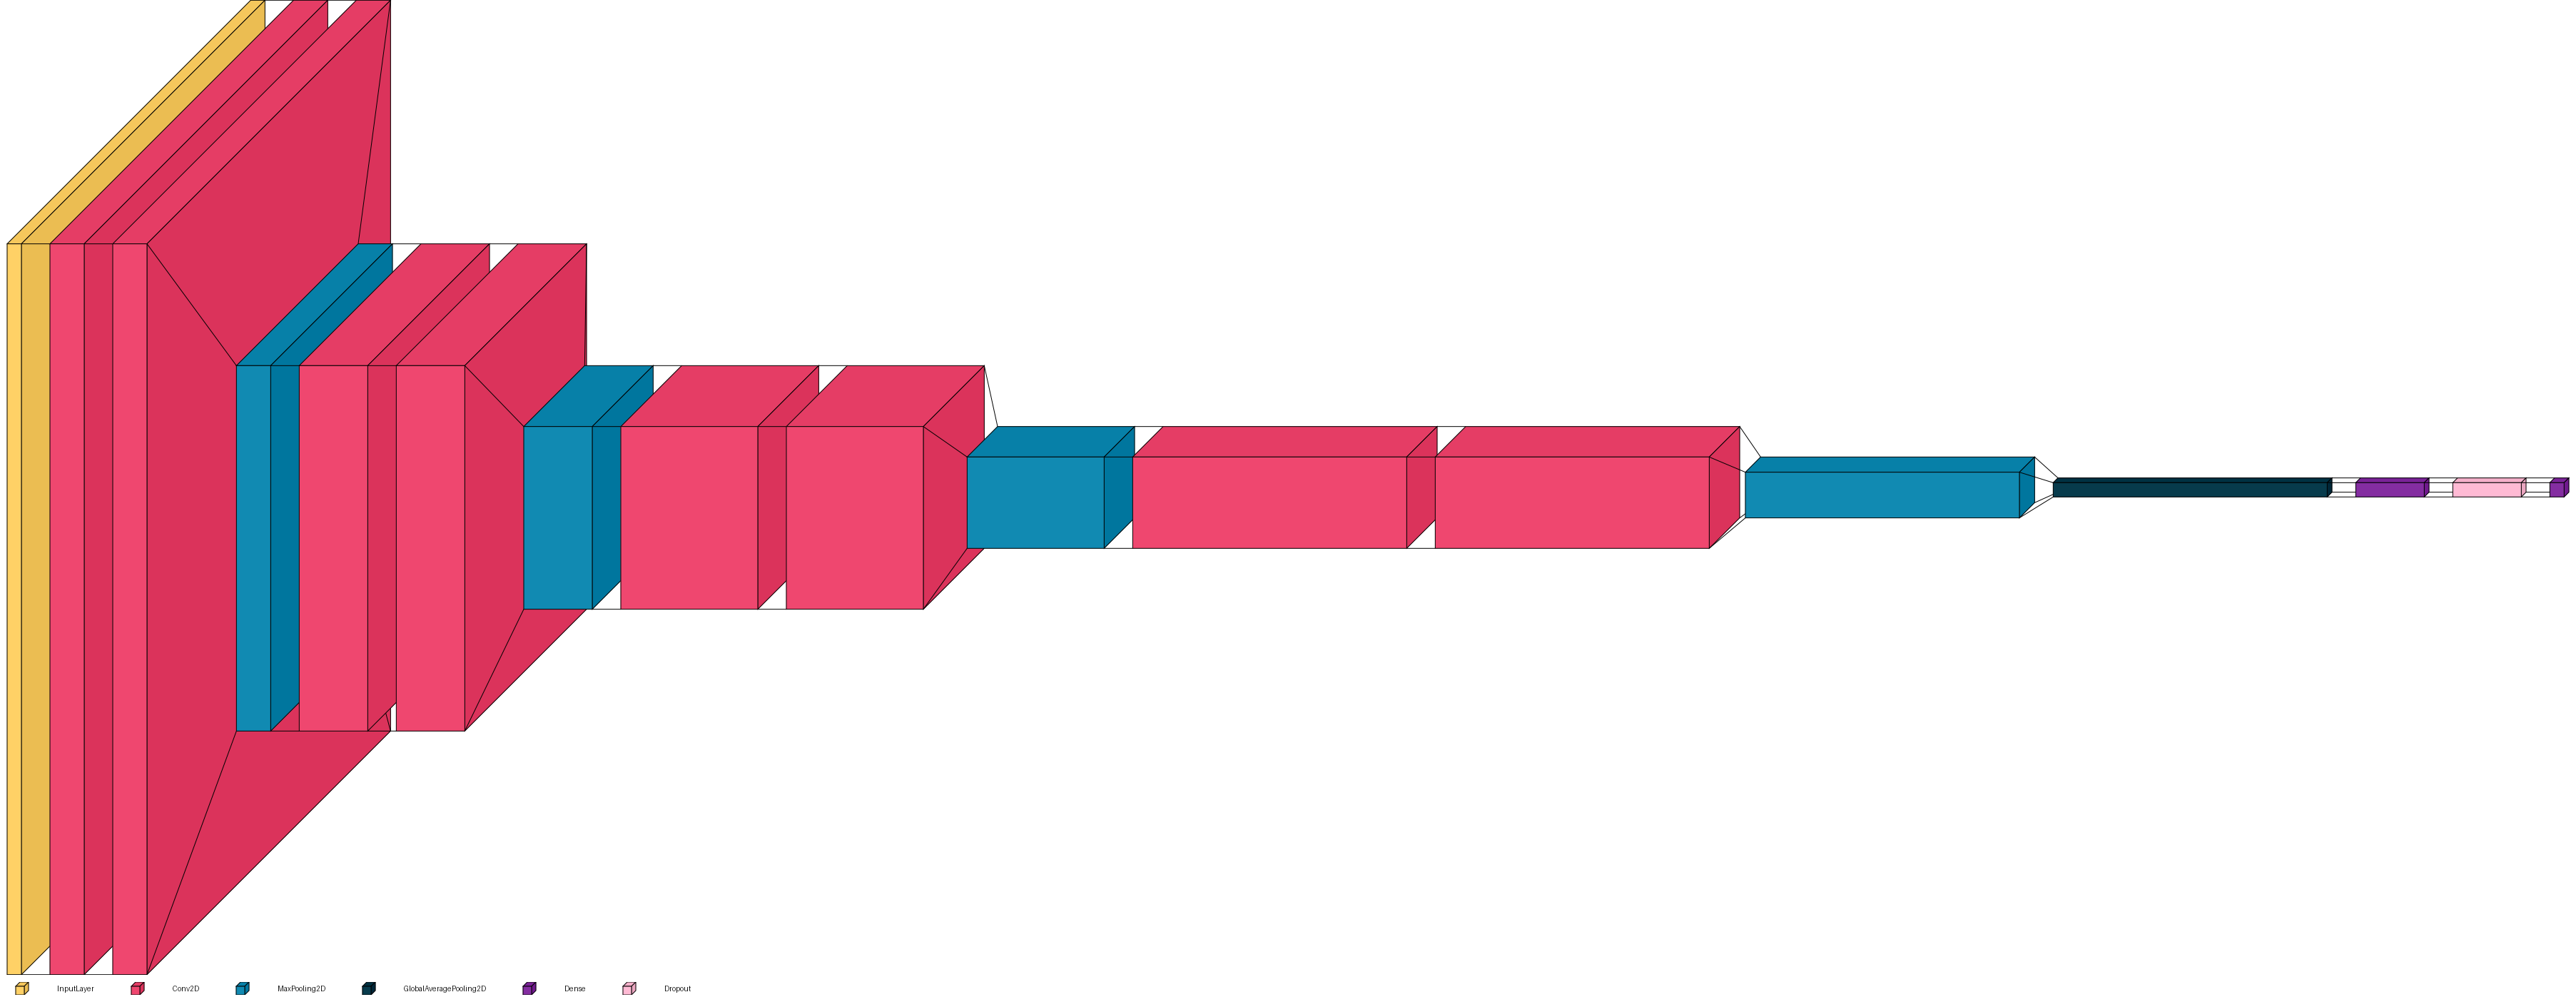

Saved: model_visualkeras.png


In [8]:
# Minimal visualkeras visualization — paste this after you create `model`
import sys, subprocess
from IPython.display import Image, display

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)

# install visualkeras + deps if missing
try:
    import visualkeras
except Exception:
    pip_install(["visualkeras", "pillow", "aggdraw"])
    import visualkeras

import tensorflow as tf

def _int_shape(x):
    try:
        return tf.keras.backend.int_shape(x)
    except Exception:
        return None

def patch_output_shapes(m):
    patched = []
    for layer in m.layers:
        if getattr(layer, "output_shape", None) is None:
            inferred = None
            out = getattr(layer, "output", None)
            if out is not None:
                inferred = _int_shape(out) if not isinstance(out, (list, tuple)) else [_int_shape(o) for o in out]
            if inferred is None:
                for a in ("batch_input_shape", "_batch_input_shape", "input_shape"):
                    inferred = getattr(layer, a, None)
                    if inferred is not None:
                        break
            if inferred is not None:
                try:
                    setattr(layer, "output_shape", inferred)
                    patched.append((layer.name, inferred))
                except Exception:
                    pass
    return patched

# Helper: build a short kernel string for Conv2D layers
def conv_kernel_str(layer):
    try:
        # Prefer reading kernel weights for robust channel info
        w = layer.get_weights()
        if w and hasattr(w[0], "shape"):
            kh, kw, in_ch, out_ch = w[0].shape
        else:
            # Fallback to layer attributes
            kh, kw = layer.kernel_size if hasattr(layer, "kernel_size") else (None, None)
            out_ch = getattr(layer, "filters", None)
            in_ch = None
            if getattr(layer, "input_shape", None) is not None:
                ish = layer.input_shape
                if isinstance(ish, tuple):
                    in_ch = ish[-1]
        return f"{kh}x{kw}x{in_ch}->{out_ch}"
    except Exception:
        return None

print("Patching shapes (if needed)...")
patched = patch_output_shapes(model)
if patched:
    for name, s in patched:
        print("patched", name, "->", s)
else:
    print("no patches applied")

# Append kernel dimensions to Conv2D layer names temporarily for visualization.
orig_names = {}
renamed = []
try:
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            kstr = conv_kernel_str(layer)
            if kstr:
                orig_names[layer] = layer.name
                # use the private attribute to avoid recreating layers
                try:
                    layer._name = f"{layer.name}\\n[{kstr}]"
                    renamed.append((layer.name, layer._name))
                except Exception:
                    # best-effort; ignore failures
                    pass

    if renamed:
        print("Renamed layers for visualization (original -> annotated):")
        for o, n in renamed:
            print(" ", o, "->", n)
    else:
        print("No Conv2D layers renamed (no kernel info available)")

    OUT = "model_visualkeras.png"
    try:
        img = visualkeras.layered_view(model, legend=True, scale_xy=2, spacing=40)
        if img is None:
            raise RuntimeError("visualkeras returned None")
        img.save(OUT)
        display(Image(OUT))
        print("Saved:", OUT)
    except Exception as e:
        print("visualkeras failed:", e)
        try:
            visualkeras.layered_view(model, to_file=OUT, legend=True, scale_xy=2, spacing=40)
            display(Image(OUT))
            print("Saved fallback:", OUT)
        except Exception as e2:
            print("fallback failed:", e2)
            print("\nModel summary:")
            model.summary()
finally:
    # Restore original layer names to avoid side-effects for subsequent cells
    for layer, orig in orig_names.items():
        try:
            layer._name = orig
        except Exception:
            pass

In [8]:
# Compile the model and prepare callbacks for training.
# Comments:
# - We use Adam optimizer and sparse categorical crossentropy (labels are integer class ids).
# - Callbacks help save the best model and stop training early if validation performance stops improving.

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()]
)

# Callbacks
os.makedirs('checkpoints', exist_ok=True)
ckpt_path = 'checkpoints/best_model.h5'
cb_list = [
    callbacks.ModelCheckpoint(
        ckpt_path, 
        monitor='val_sparse_categorical_accuracy', 
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_sparse_categorical_accuracy', 
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_sparse_categorical_accuracy', 
        factor=0.5, 
        patience=5,
        verbose=1,
        min_lr=1e-7,
    )
]

# Prepare datasets for training. Note: this cell sets a reduced `batch_size` to lower RAM usage.
# If you previously instantiated datasets with a different batch_size, this will rebuild them
# using the new value. Reduce this further if you hit GPU OOM (try 2 or 1).
batch_size = 4
train_ds_rep = build_dataset_index(train_idx, batch_size=batch_size, shuffle=True, training=True, repeat=True)
val_ds = build_dataset_index(val_idx, batch_size=batch_size, shuffle=False, training=False, repeat=False)
test_ds = build_dataset_index(test_idx, batch_size=batch_size, shuffle=False, training=False, repeat=False)

# Determine how many steps the training loop will take per epoch. These are integer divisions
# of the number of samples in each split by the batch size.
steps_per_epoch = max(1, len(train_idx) // batch_size)
validation_steps = max(1, len(val_idx) // batch_size)

print(f"\nStarting training")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print(f"Batch size: {batch_size}\n")

# Train the model. `callbacks` will handle saving the best weights and learning rate adjustments.
history = model.fit(
    train_ds_rep,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=cb_list,
    verbose=1,
)

print("Training completed")

# After training you can inspect `history.history` for per-epoch metrics and plot them (next cell).


Starting training
Steps per epoch: 1050
Validation steps: 225
Batch size: 4

Epoch 1/50


2025-10-22 16:02:25.792491: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f520c00c0c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-22 16:02:25.792510: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2025-10-22 16:02:25.821192: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-22 16:02:26.276670: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
2025-10-22 16:02:26.276670: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
2025-10-22 16:02:35.326801: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f16[32,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[4,512,512,32]{3,2,1,0}, f16[4,512,512,32]{3,2

   3/1050 ━━━━━━━━━━━━━━━━━━━━ 49s 48ms/step - loss: 1.7885 - sparse_categorical_accuracy: 0.2500   

I0000 00:00:1761166973.756521    5716 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.8915 - sparse_categorical_accuracy: 0.6092
Epoch 1: val_sparse_categorical_accuracy improved from None to 1.00000, saving model to checkpoints/best_model.h5

Epoch 1: val_sparse_categorical_accuracy improved from None to 1.00000, saving model to checkpoints/best_model.h5


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 87s 53ms/step - loss: 0.4701 - sparse_categorical_accuracy: 0.8055 - val_loss: 0.0136 - val_sparse_categorical_accuracy: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/50
Epoch 2/50
1049/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1300 - sparse_categorical_accuracy: 0.9506
Epoch 2: val_sparse_categorical_accuracy did not improve from 1.00000
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 55s 52ms/step - loss: 0.1239 - sparse_categorical_accuracy: 0.9555 - val_loss: 0.0101 - val_sparse_categorical_accuracy: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50

Epoch 2: val_sparse_categorical_accuracy did not improve from 1.00000
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 55s 52ms/step - loss: 0.1239 - sparse_categorical_accuracy: 0.9555 - val_loss: 0.0101 - val_sparse_categorical_accuracy: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50
1049/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0965 - sparse_categorical_accuracy: 0.9701
Epoch 3: val_sparse_categorical_accuracy did not improve fro

In [ ]:
df = pd.DataFrame(history.history)
df.index += 1  # start epochs at 1 for easier reading
df.to_csv('training_history.csv', index_label='epoch')

In [10]:
# Utilities: save convolutional kernels (filters) and activations for example images
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

def _ensure_dir(d):
    os.makedirs(d, exist_ok=True)

def _normalize_img(img):
    # Normalize to 0..1 for visualization (handles constant maps too).
    mn, mx = img.min(), img.max()
    if mx - mn < 1e-12:
        return np.zeros_like(img)
    return (img - mn) / (mx - mn)

def get_conv_layers(model):
    # return only Conv2D layers in model (in order)
    return [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]

def save_filters(layer, out_dir, max_filters=64, cmap='seismic'):
    """Save learned filters (kernels) of a Conv2D layer to PNG files."""
    _ensure_dir(out_dir)
    weights = layer.get_weights()
    if len(weights) == 0:
        print(f'Layer {layer.name} has no weights')
        return
    kernel = weights[0]  # shape (kh,kw,in_ch,out_ch)
    if kernel.ndim != 4:
        print(f'Unexpected kernel shape for {layer.name}:', kernel.shape)
        return
    kh, kw, in_ch, out_ch = kernel.shape
    n = min(out_ch, max_filters)
    for i in range(n):
        # If input has multiple channels, average them for visualization
        filt = kernel[:, :, :, i]
        if in_ch > 1:
            filt = filt.mean(axis=2)
        else:
            filt = filt[:, : , 0]
        img = _normalize_img(filt)
        path = os.path.join(out_dir, f'filter_{i:03d}.png')
        plt.imsave(path, img, cmap=cmap)
    print(f'Saved {n} filters for layer {layer.name} ->', out_dir)

def save_all_kernels(model, base_dir='kernels', max_filters_per_layer=64):
    convs = get_conv_layers(model)
    for i, l in enumerate(convs):
        out = os.path.join(base_dir, f'layer_{i}_{l.name}')
        save_filters(l, out, max_filters=max_filters_per_layer)

def save_activations(model, images, out_dir='activations_samples', max_channels=16, cmap='inferno'):
    """Run `images` (numpy array HWC or NHWC) through the model and save activation maps for each conv layer."""
    _ensure_dir(out_dir)
    # Ensure input shape is NHWC and float32
    imgs = np.array(images, dtype=np.float32)
    if imgs.ndim == 3:
        imgs = imgs[..., np.newaxis]
    # Build a model that outputs all conv layer outputs
    convs = get_conv_layers(model)
    if len(convs) == 0:
        print('No Conv2D layers found in model')
        return
    outputs = [l.output for l in convs]
    act_model = tf.keras.Model(inputs=model.input, outputs=outputs)
    # Run prediction (inference) — small number of images, so batch prediction is fine
    acts = act_model.predict(imgs)
    # acts is a list: one array per conv layer: (N, H, W, C)
    for li, act in enumerate(acts):
        layer = convs[li]
        layer_dir = os.path.join(out_dir, f'layer_{li}_{layer.name}')
        _ensure_dir(layer_dir)
        N, H, W, C = act.shape
        ch_to_save = min(C, max_channels)
        for n in range(N):
            # create a subdir per image for clarity
            img_dir = os.path.join(layer_dir, f'img_{n}')
            _ensure_dir(img_dir)
            for c in range(ch_to_save):
                m = act[n, :, :, c]
                m_norm = _normalize_img(m)
                fname = os.path.join(img_dir, f'ch_{c:03d}.png')
                plt.imsave(fname, m_norm, cmap=cmap)
        print(f'Saved activations for layer {layer.name} (N={N}) ->', layer_dir)

class ActivationLogger(tf.keras.callbacks.Callback):
    """Keras callback that saves activations for a small set of sample images after each epoch."""
    def __init__(self, sample_images, base_dir='activations_by_epoch', max_channels=8, every_n_epochs=1):
        super().__init__()
        self.sample_images = np.array(sample_images, dtype=np.float32)
        if self.sample_images.ndim == 3:
            self.sample_images = self.sample_images[..., np.newaxis]
        self.base_dir = base_dir
        self.max_channels = max_channels
        self.every_n_epochs = every_n_epochs
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs != 0:
            return
        out = os.path.join(self.base_dir, f'epoch_{epoch+1:03d}')
        save_activations(self.model, self.sample_images, out_dir=out, max_channels=self.max_channels)
        # also save kernels snapshot at this epoch
        save_all_kernels(self.model, base_dir=os.path.join(out, 'kernels'))
        print(f'ActivationLogger: saved activations+kernels for epoch {epoch+1} ->', out)

print('Utilities loaded: save_all_kernels, save_activations, ActivationLogger')

Utilities loaded: save_all_kernels, save_activations, ActivationLogger


In [ ]:
# Example: pick a few sample images from test_ds and save kernels+activations
# Note: run this cell AFTER you have loaded/created `model` and `test_ds`.

# How many sample images to save (keep small to avoid large output)
n_samples = 3
# Try to fetch a single batch from test_ds
try:
    batch = next(iter(test_ds.take(1)))
    imgs = batch[0].numpy()[:n_samples]
except Exception as e:
    print('Could not read from test_ds automatically:', e)
    # Fall back to reading images with the index helper if available (first few test_idx)
    imgs = []
    for i in list(test_idx)[:n_samples]:
        g, idx, k = indices[i]
        im = read_image(h5_path, g, idx)
        if im.ndim == 2:
            im = im[..., np.newaxis]
        imgs.append(im)
    imgs = np.array(imgs, dtype=np.float32)

print('Sample images shape:', imgs.shape)

# Save activations for these samples (will create activations_samples/...)
save_activations(model, imgs, out_dir='activations_samples', max_channels=8)
# Save kernels for all conv layers (kernels/...)
save_all_kernels(model, base_dir='kernels', max_filters_per_layer=64)


Sample images shape: (3, 512, 512, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Saved activations for layer conv2d (N=3) -> activations_samples/layer_0_conv2d
Saved activations for layer conv2d (N=3) -> activations_samples/layer_0_conv2d
Saved activations for layer conv2d_1 (N=3) -> activations_samples/layer_1_conv2d_1
Saved activations for layer conv2d_1 (N=3) -> activations_samples/layer_1_conv2d_1
Saved activations for layer conv2d_2 (N=3) -> activations_samples/layer_2_conv2d_2
Saved activations for layer conv2d_2 (N=3) -> activations_samples/layer_2_conv2d_2
Saved activations for layer conv2d_3 (N=3) -> activations_samples/layer_3_conv2d_3
Saved activations for layer conv2d_4 (N=3) -> activations_samples/layer_4_conv2d_4
Saved activations for layer conv2d_3 (N=3) -> activations_samples/layer_3_conv2d_3
Saved activations for layer conv2d_4 (N=3) -> activations_samples/layer_4_conv2d_4


/tmp/ipykernel_5154/1937779939.py:16: RuntimeWarning: invalid value encountered in divide
  return (img - mn) / (mx - mn)


Saved activations for layer conv2d_5 (N=3) -> activations_samples/layer_5_conv2d_5
Saved activations for layer conv2d_6 (N=3) -> activations_samples/layer_6_conv2d_6
Saved activations for layer conv2d_7 (N=3) -> activations_samples/layer_7_conv2d_7
Saved 32 filters for layer conv2d -> kernels/layer_0_conv2d
Saved 32 filters for layer conv2d_1 -> kernels/layer_1_conv2d_1
Saved 64 filters for layer conv2d_2 -> kernels/layer_2_conv2d_2
Saved 64 filters for layer conv2d_3 -> kernels/layer_3_conv2d_3
Saved 64 filters for layer conv2d_4 -> kernels/layer_4_conv2d_4
Saved 64 filters for layer conv2d_5 -> kernels/layer_5_conv2d_5
Saved 64 filters for layer conv2d_6 -> kernels/layer_6_conv2d_6
Saved 64 filters for layer conv2d_7 -> kernels/layer_7_conv2d_7
Saved 64 filters for layer conv2d_4 -> kernels/layer_4_conv2d_4
Saved 64 filters for layer conv2d_5 -> kernels/layer_5_conv2d_5
Saved 64 filters for layer conv2d_6 -> kernels/layer_6_conv2d_6
Saved 64 filters for layer conv2d_7 -> kernels/laye